# 1.5 — Heatmaps

Three heatmaps:
1. Team touch map for one match (Barcelona vs Athletic Club, La Liga 2015/16)
2. Messi touch map across the entire 2015/16 La Liga season
3. Pressing heatmap for Bayer Leverkusen (Bundesliga 2023/24)

In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

sys.path.append('/Users/stefanhofmann/Documents/Bewerbung/Portfolio/Blog/assets/helpers')
from data_loader import load_competitions, load_matches, load_events, flatten_events

DATA_DIR = '/Users/stefanhofmann/Documents/Bewerbung/Interviews/Hudl/statsbomb_explorer/open-data/data'
FIGURES  = 'figures'

---
## Part 1: Team Touch Map — One Match

In [2]:
MATCH_ID = 266149

comp_df = load_competitions()
row = comp_df[
    (comp_df['competition_name'] == 'La Liga') &
    (comp_df['season_name'] == '2015/2016')
].iloc[0]

matches = load_matches(row['competition_id'], row['season_id'])
match_row = matches[matches['match_id'] == MATCH_ID].iloc[0]

home_team = match_row['home_team']['home_team_name']
away_team  = match_row['away_team']['away_team_name']

raw = load_events(MATCH_ID)
df  = flatten_events(raw)

touches_barca = df[
    (df['team'] == home_team) &
    df['x'].notna()
].copy()

print(f'{home_team} vs {away_team}')
print(f'Total {home_team} touches with location: {len(touches_barca)}')

Barcelona vs Athletic Club
Total Barcelona touches with location: 2522


### 2D Histogram

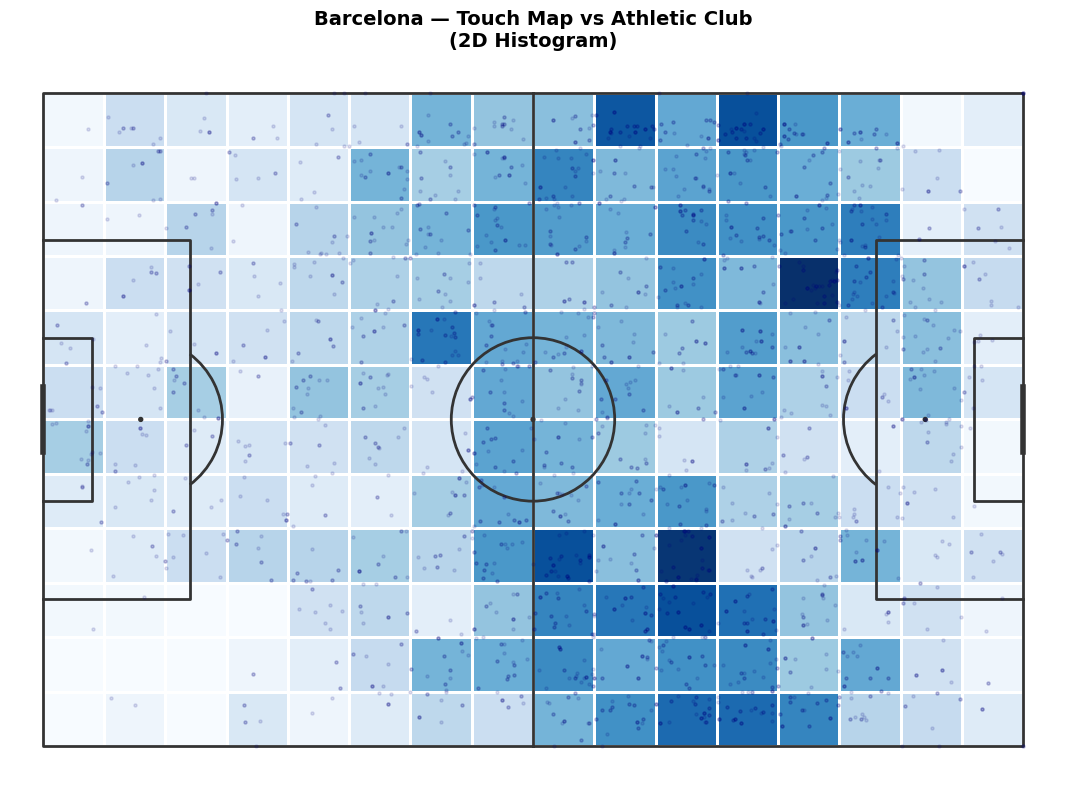

In [3]:
pitch = Pitch(pitch_color='white', line_color='#333333', line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

bin_statistic = pitch.bin_statistic(
    touches_barca['x'], touches_barca['y'],
    statistic='count', bins=(16, 12)
)
pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='white')
pitch.scatter(touches_barca['x'], touches_barca['y'],
              ax=ax, s=5, color='navy', alpha=0.12, zorder=3)

ax.set_title(f'{home_team} — Touch Map vs {away_team}\n(2D Histogram)',
             fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES}/team_touch_hist.png', dpi=150, bbox_inches='tight')
plt.show()

### KDE — Smooth Density

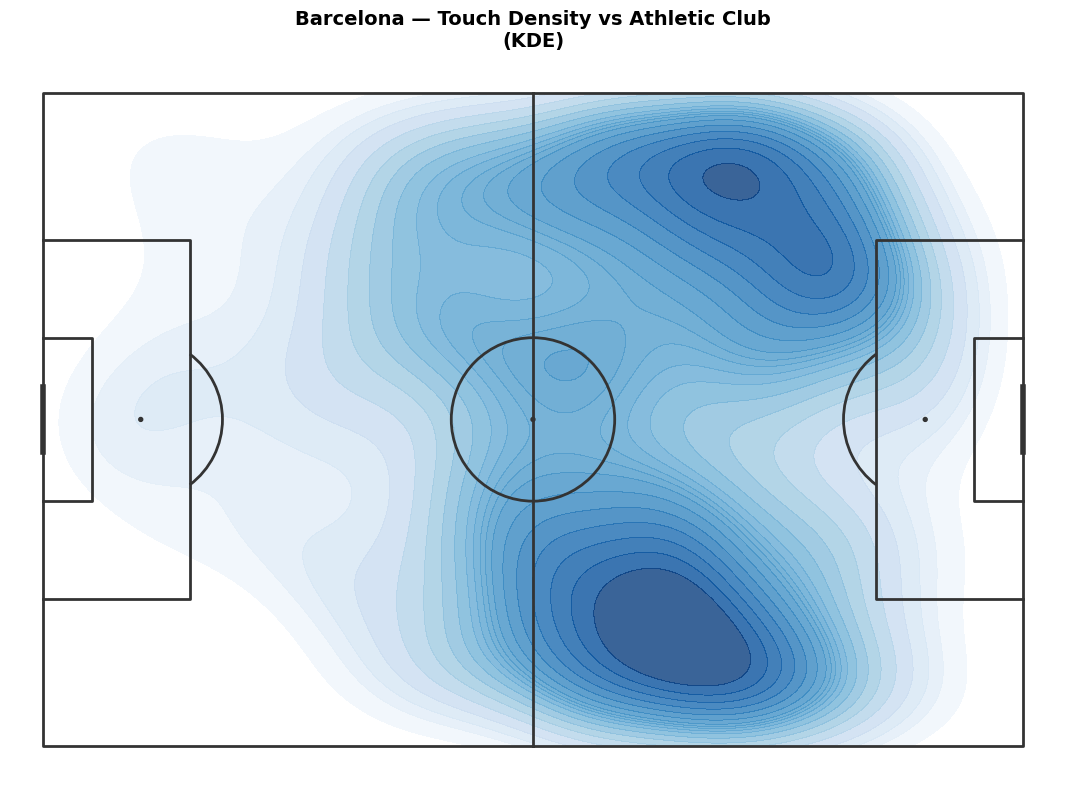

In [4]:
pitch = Pitch(pitch_color='white', line_color='#333333', line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.kdeplot(
    touches_barca['x'], touches_barca['y'],
    ax=ax, cmap='Blues', levels=20, fill=True, alpha=0.8
)

ax.set_title(f'{home_team} — Touch Density vs {away_team}\n(KDE)',
             fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES}/team_touch_kde.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Messi Touch Map — Full Season (La Liga 2015/16)

In [5]:
all_messi_touches = []

for _, match in matches.iterrows():
    mid  = match['match_id']
    path = os.path.join(DATA_DIR, 'events', f'{mid}.json')
    if not os.path.exists(path):
        continue
    with open(path) as f:
        raw_m = json.load(f)
    events = flatten_events(raw_m)
    messi = events[
        (events['player'] == 'Lionel Andr\u00e9s Messi Cuccittini') &
        events['x'].notna()
    ].copy()
    if len(messi) > 0:
        all_messi_touches.append(messi)

messi_df = pd.concat(all_messi_touches, ignore_index=True)
print(f'Messi touches in La Liga 2015/16: {len(messi_df)}')

Messi touches in La Liga 2015/16: 7370


In [ ]:
pitch = Pitch(pitch_color='#1a1a1a', line_color='#555555', line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a1a')

pitch.kdeplot(
    messi_df['x'], messi_df['y'],
    ax=ax, cmap='YlOrRd', levels=30, fill=True, alpha=0.85
)

ax.set_title('Lionel Messi — La Liga 2015/16\nTouch Density',
             fontweight='bold', fontsize=14, color='white', pad=12)
plt.tight_layout()
plt.savefig(f'{FIGURES}/messi_touch_map.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

---
## Part 3: Pressing Heatmap — Bayer Leverkusen

In [7]:
MATCH_ID_LEV = 3895302

comp_row_lev = comp_df[
    (comp_df['competition_name'] == '1. Bundesliga') &
    (comp_df['season_name'] == '2023/2024')
].iloc[0]

matches_lev = load_matches(comp_row_lev['competition_id'], comp_row_lev['season_id'])

raw_lev = load_events(MATCH_ID_LEV)
df_lev  = flatten_events(raw_lev)

pressure_lev = df_lev[
    (df_lev['type'] == 'Pressure') &
    (df_lev['team'] == 'Bayer Leverkusen') &
    df_lev['x'].notna()
].copy()

print(f'Leverkusen pressure events: {len(pressure_lev)}')

Leverkusen pressure events: 220


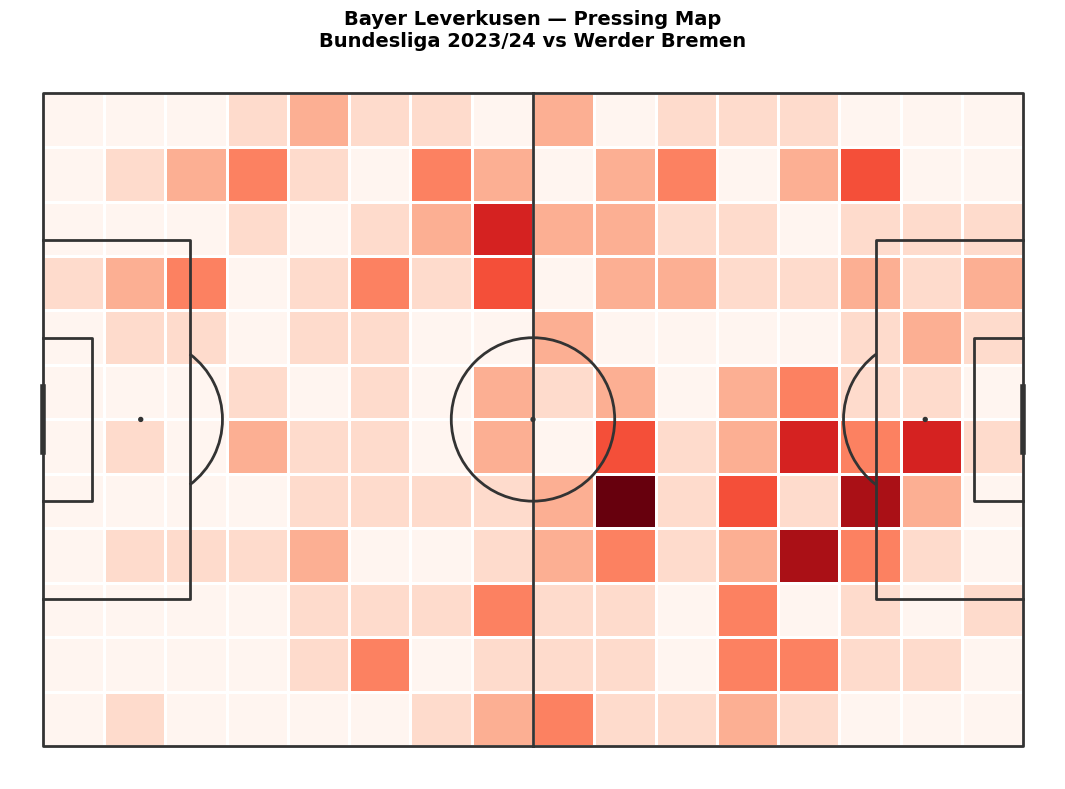

In [8]:
pitch = Pitch(pitch_color='white', line_color='#333333', line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

bin_stat = pitch.bin_statistic(
    pressure_lev['x'], pressure_lev['y'],
    statistic='count', bins=(16, 12)
)
pitch.heatmap(bin_stat, ax=ax, cmap='Reds', edgecolors='white')

ax.set_title('Bayer Leverkusen — Pressing Map\nBundesliga 2023/24 vs Werder Bremen',
             fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES}/pressing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Both Teams Side by Side

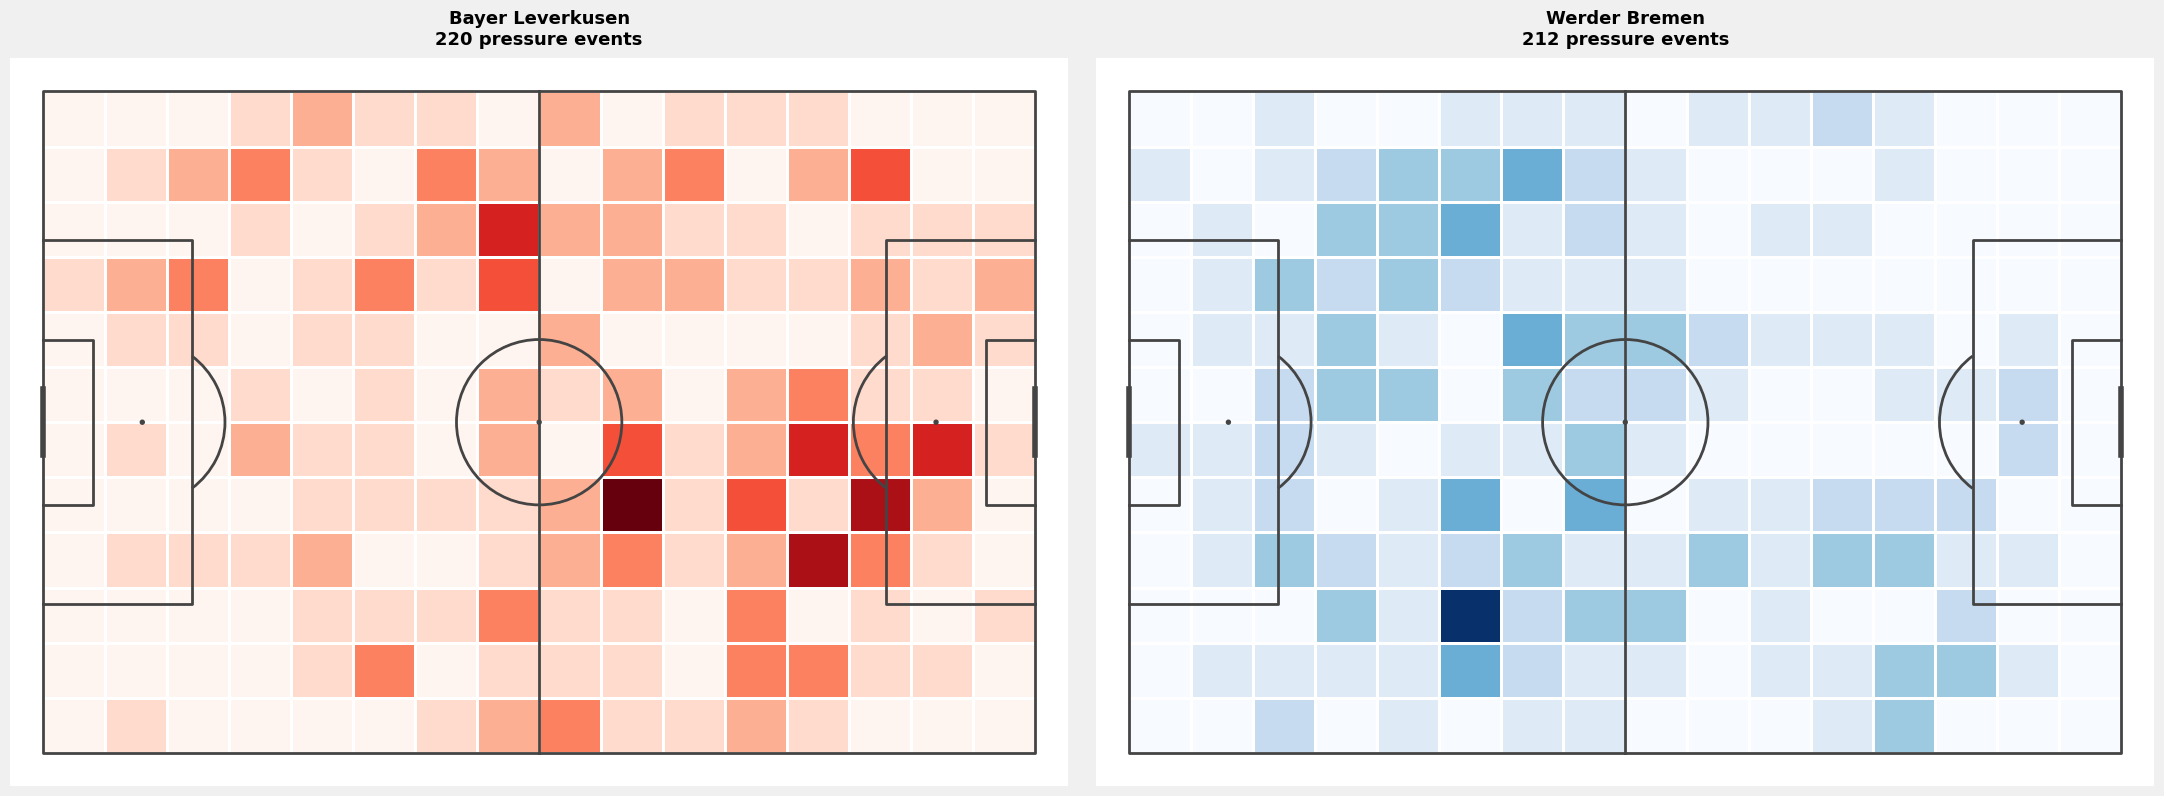

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.patch.set_facecolor('#f0f0f0')

teams_lev = ['Bayer Leverkusen', 'Werder Bremen']
cmaps_lev = ['Reds', 'Blues']

for ax, team, cmap in zip(axes, teams_lev, cmaps_lev):
    pitch = Pitch(pitch_color='white', line_color='#444444', line_zorder=2)
    pitch.draw(ax=ax)

    tp = df_lev[
        (df_lev['type'] == 'Pressure') &
        (df_lev['team'] == team) &
        df_lev['x'].notna()
    ]
    bs = pitch.bin_statistic(tp['x'], tp['y'], statistic='count', bins=(16, 12))
    pitch.heatmap(bs, ax=ax, cmap=cmap, edgecolors='white')
    ax.set_title(f'{team}\n{len(tp)} pressure events', fontweight='bold', fontsize=13, pad=10)

plt.tight_layout(pad=2)
plt.savefig(f'{FIGURES}/pressing_both_teams.png', dpi=150, bbox_inches='tight')
plt.show()

---
**End of Series 1.** Next up: Series 2 — Tactical Analysis, starting with a proper breakdown of xG models.